# Sparse Connectivity Prediction with LASSO

Predict each functional connection from structural network features using LASSO, compare prediction errors with a direct-connection baseline, and inspect selected features.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## LASSO Regression

For each functional edge, a LASSO model was fitted using each unique structural connection (upper triangle in the matrix) as features. Features were standardised (0 mean, unit variance) prior to fitting. The regularisation parameter $\alpha$ was selected by 5-fold cross-validation, and predictive performance was evaluated using LOOCV MSE. The baseline to compare LASSO regression to was the model with only the direct structural connection $s_{ij}$.

In [1]:
from pathlib import Path
figure_dir = Path("figures/lasso_connectivity_prediction")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error

base_path = "data/connectomes/"

def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break
    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]
    df = pd.read_csv(path, header=None, comment="#")
    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names
    return df

structural, functional = {}, {}
for pid in range(32, 51):
    structural[pid] = load_connectome(f"{base_path}{pid}_WFA_68.csv")
    functional[pid] = load_connectome(f"{base_path}{pid}_rsfMRI_68.csv")

subjects  = sorted(structural.keys())
n_subj    = len(subjects)
n_regions = structural[subjects[0]].shape[0]
print(f"Loaded {n_subj} subjects, {n_regions} regions.")

Loaded 19 subjects, 68 regions.


In [2]:
mask_upper  = np.triu(np.ones((n_regions, n_regions), dtype=bool), k=1)
edge_pairs  = list(zip(*np.where(mask_upper)))   # list of (i, j) tuples
n_edges     = len(edge_pairs)
regions     = structural[subjects[0]].index.tolist()

# Structural feature matrix and functional target matrix
X_struct = np.zeros((n_subj, n_edges), dtype=np.float32)
F_mat    = np.zeros((n_subj, n_edges), dtype=np.float32)

for s_idx, pid in enumerate(subjects):
    X_struct[s_idx] = structural[pid].values[mask_upper]
    F_mat[s_idx]    = functional[pid].values[mask_upper]

# Standardise structural features (zero mean, unit std)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_struct)

print(f"Feature matrix X: {X_struct.shape}  (subjects × structural edges)")
print(f"Target matrix  F: {F_mat.shape}  (subjects × functional edges)")
print(f"X mean after scaling: {X_scaled.mean():.6f}  std: {X_scaled.std():.4f}")

# Also flag which edges have any structural connectivity across subjects
struct_present = (X_struct > 0).sum(axis=0)
print(f"\nStructural edges present in ≥10/19 subjects: {(struct_present >= 10).sum()}")
print(f"Structural edges present in ≥1 subject:      {(struct_present >= 1).sum()}")

Feature matrix X: (19, 2278)  (subjects × structural edges)
Target matrix  F: (19, 2278)  (subjects × functional edges)
X mean after scaling: 0.000000  std: 0.8174

Structural edges present in ≥10/19 subjects: 803
Structural edges present in ≥1 subject:      1522


In [3]:
loo = LeaveOneOut()

ols_mse = np.zeros(n_edges)
for idx in range(n_edges):
    y = F_mat[:, idx]
    x = X_struct[:, idx]           # direct structural weight s_ij

    if x.max() == 0:               # no structural connection for any subject
        ols_mse[idx] = np.var(y)   # null model: predict the mean
        continue

    X_ols = sm.add_constant(x)
    preds = []
    for train, test in loo.split(X_ols):
        m = sm.OLS(y[train], X_ols[train]).fit()
        preds.append(m.predict(X_ols[test])[0])
    ols_mse[idx] = mean_squared_error(y, preds)

print(f"OLS LOOCV MSE  —  mean: {ols_mse.mean():.6f}  median: {np.median(ols_mse):.6f}")

OLS LOOCV MSE  —  mean: 0.003375  median: 0.003063


In [4]:
import os
import warnings
from joblib import Parallel, delayed, parallel_config


def fit_lasso_edge(idx):
    # Preserve the original fitting procedure; each edge is independent.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y = F_mat[:, idx].astype(np.float64)
        lasso_cv = LassoCV(cv=5, max_iter=10000, n_alphas=50, random_state=0)
        lasso_cv.fit(X_scaled, y)
        best_alpha = lasso_cv.alpha_

        lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
        y_pred_loo = cross_val_predict(lasso_model, X_scaled, y, cv=loo)
        error = mean_squared_error(y, y_pred_loo)

        lasso_model.fit(X_scaled, y)
        nonzero = np.where(lasso_model.coef_ != 0)[0]
    return idx, error, best_alpha, nonzero


lasso_mse = np.zeros(n_edges)
lasso_alpha = np.zeros(n_edges)
lasso_n_selected = np.zeros(n_edges, dtype=int)
selected_features = [None] * n_edges

workers = min(6, os.cpu_count() or 1)
with parallel_config(backend="loky", n_jobs=workers, inner_max_num_threads=1):
    results = Parallel(return_as="generator")(
        delayed(fit_lasso_edge)(idx) for idx in range(n_edges)
    )
    for idx, error, best_alpha, nonzero in results:
        lasso_mse[idx] = error
        lasso_alpha[idx] = best_alpha
        lasso_n_selected[idx] = len(nonzero)
        selected_features[idx] = nonzero
        if idx % 100 == 0:
            print(f"  {idx}/{n_edges}  mse={error:.5f}  alpha={best_alpha:.4f}  features={len(nonzero)}", flush=True)

print(f"\nDone. LASSO LOOCV MSE ? mean: {lasso_mse.mean():.6f}  median: {np.median(lasso_mse):.6f}")


  0/2278  mse=0.00259  alpha=0.0347  features=0


  100/2278  mse=0.01091  alpha=0.0001  features=22


  200/2278  mse=0.00173  alpha=0.0255  features=1


  300/2278  mse=0.00286  alpha=0.0337  features=0


  400/2278  mse=0.00106  alpha=0.0075  features=12


...

  1900/2278  mse=0.00385  alpha=0.0197  features=10


  2000/2278  mse=0.00307  alpha=0.0344  features=0


  2100/2278  mse=0.00221  alpha=0.0287  features=1


  2200/2278  mse=0.00128  alpha=0.0000  features=24



Done. LASSO LOOCV MSE ? mean: 0.003187  median: 0.002921


In [5]:
improvement = ols_mse - lasso_mse          # positive = LASSO better
pct_better  = (improvement / ols_mse) * 100

print("=" * 55)
print(f"{'Model':<20} {'Mean MSE':>10} {'Median MSE':>12}")
print("-" * 55)
print(f"{'OLS (f ~ s_ij)':<20} {ols_mse.mean():>10.6f} {np.median(ols_mse):>12.6f}")
print(f"{'LASSO':<20} {lasso_mse.mean():>10.6f} {np.median(lasso_mse):>12.6f}")
print("=" * 55)
print(f"\nEdges where LASSO < OLS:  {(improvement > 0).sum()} / {n_edges}  ({(improvement>0).mean()*100:.1f}%)")
print(f"Mean improvement:          {pct_better.mean():.2f}%")
print(f"Median improvement:        {np.median(pct_better):.2f}%")

# Summary table
summary = pd.DataFrame({
    "Model":      ["OLS (f ~ s_ij)", "LASSO (all structural features)"],
    "Mean MSE":   [ols_mse.mean(),   lasso_mse.mean()],
    "Median MSE": [np.median(ols_mse), np.median(lasso_mse)],
    "Std MSE":    [ols_mse.std(),    lasso_mse.std()],
})
print("\n", summary.round(6).to_string(index=False))

Model                  Mean MSE   Median MSE
-------------------------------------------------------
OLS (f ~ s_ij)         0.003375     0.003063
LASSO                  0.003187     0.002921

Edges where LASSO < OLS:  1273 / 2278  (55.9%)
Mean improvement:          3.08%
Median improvement:        2.38%

                           Model  Mean MSE  Median MSE  Std MSE
                 OLS (f ~ s_ij)  0.003375    0.003063 0.001718
LASSO (all structural features)  0.003187    0.002921 0.001478


**Table 6:** LASSO vs OLS baseline (LOOCV MSE across all 2278 functional edges). OLS baseline uses only the direct structural connection $s_{ij}$.

| Model | Mean MSE | Median MSE | SD MSE |
| --- | --- | --- | --- |
| OLS ($f_{ij}=\alpha_{ij}+\beta_{ij}s_{ij}$) | 0.003375 | 0.003063 | 0.001718 |
| LASSO (all 2278 structural features) | 0.003187 | 0.002921 | 0.001478 |

**Verification note:** These outputs reproduce the original protocol. The scaler and alpha selection use all subjects before the leave-one-out predictions, so this is not nested validation and its errors can be optimistic. For edges with no direct structural connection, the original OLS baseline uses the full-sample variance rather than leave-one-out mean predictions. Independent validation would require refitting preprocessing and selecting alpha within each training fold.

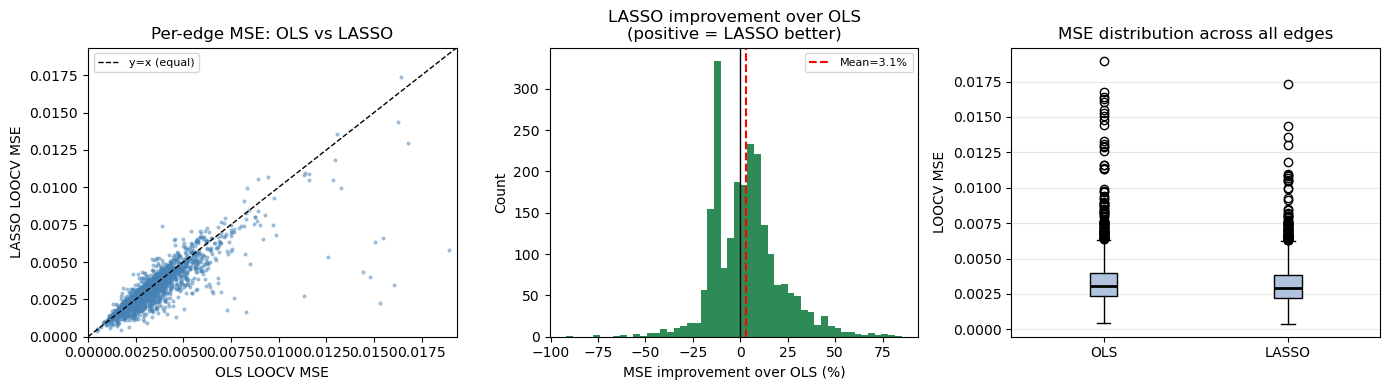

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. MSE scatter: OLS vs LASSO per edge
ax = axes[0]
ax.scatter(ols_mse, lasso_mse, s=4, alpha=0.4, color="steelblue")
lim = max(ols_mse.max(), lasso_mse.max()) * 1.02
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="y=x (equal)")
ax.set_xlabel("OLS LOOCV MSE")
ax.set_ylabel("LASSO LOOCV MSE")
ax.set_title("Per-edge MSE: OLS vs LASSO")
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)

# 2. Distribution of % improvement
ax = axes[1]
ax.hist(np.clip(pct_better, -100, 100), bins=50, color="seagreen", edgecolor="none")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(pct_better.mean(), color="red", linestyle="--", label=f"Mean={pct_better.mean():.1f}%")
ax.set_xlabel("MSE improvement over OLS (%)")
ax.set_ylabel("Count")
ax.set_title("LASSO improvement over OLS\n(positive = LASSO better)")
ax.legend(fontsize=8)

# 3. Boxplot side-by-side
ax = axes[2]
ax.boxplot([ols_mse, lasso_mse], tick_labels=["OLS", "LASSO"],
           patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue"),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("LOOCV MSE")
ax.set_title("MSE distribution across all edges")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(figure_dir / 'lasso_vs_ols.png'), dpi=180, bbox_inches="tight")
plt.show()

**Figure 5:** Per-edge LOOCV MSE: OLS vs LASSO scatter (left), distribution of proportional improvement (centre), and side-by-side boxplot (right). Points below the diagonal indicate edges where LASSO outperforms OLS.

## LASSO-based Prediction

LASSO achieves a lower mean LOOCV MSE than the linear model in 55.9% of the edges, with a mean and median improvement of 3.1% and 2.4% respectively. The variance of MSE also decreases under LASSO, which means more stable predictions. The edges (44.1%) where the linear model outperforms LASSO are mostly edges with strong direct structural connections, which may mean that the LASSO penalty is too aggressive.

Features selected per functional edge:
  Mean:    5.69
  Median:  1.0
  Min/Max: 0 / 35
  Edges with 0 selected: 780 (34.2%)


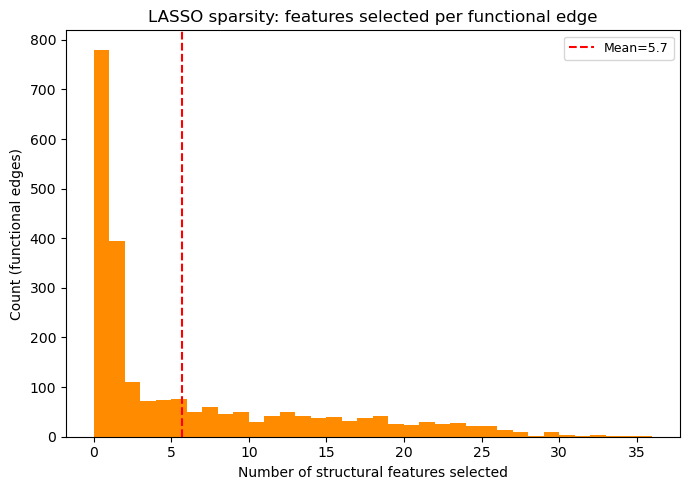

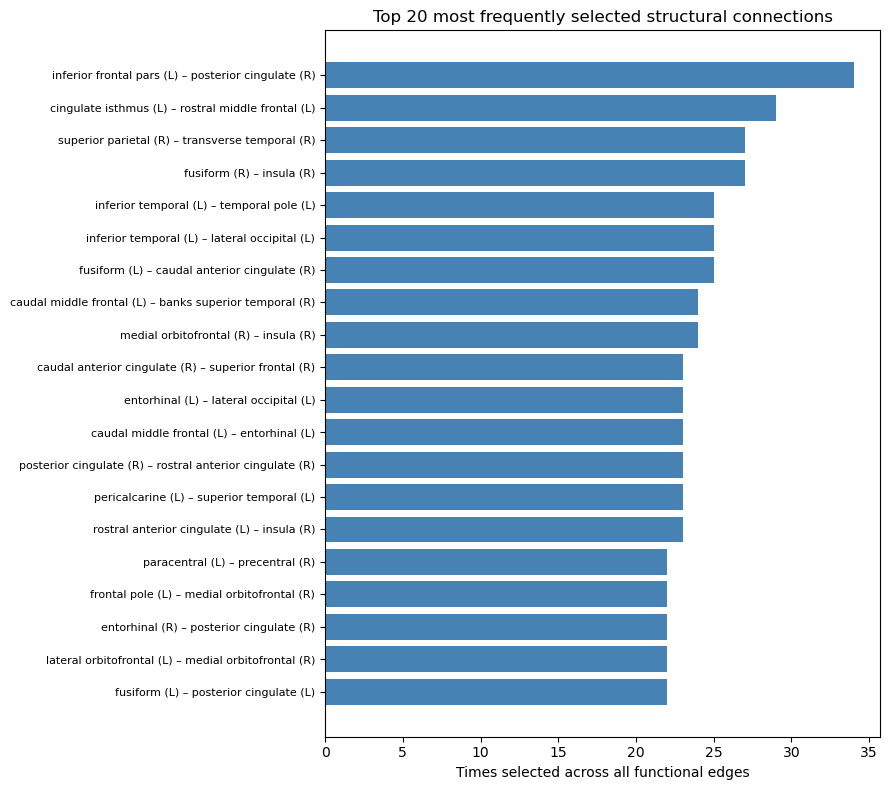

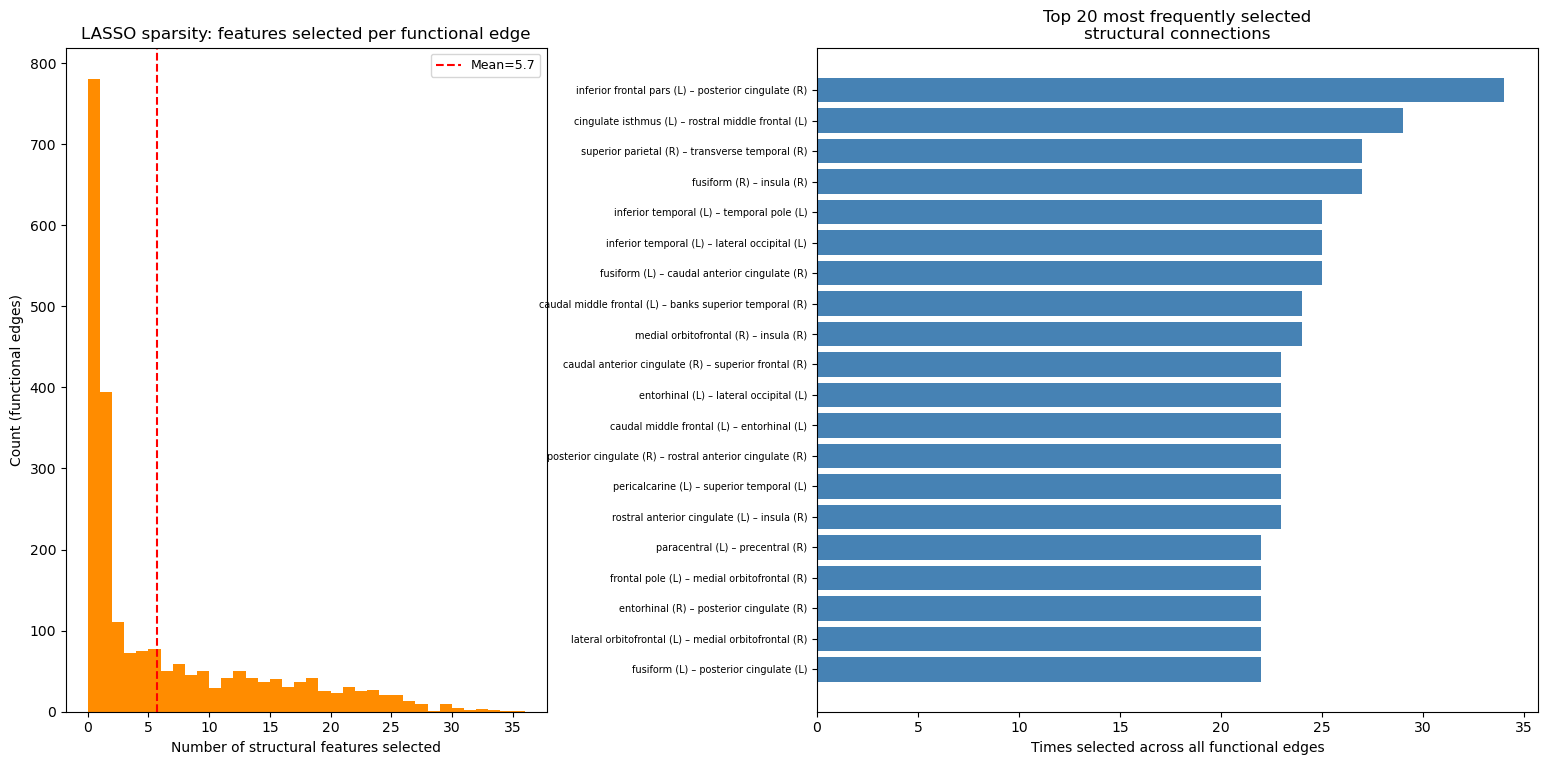

In [7]:
def short_label(name):
    hemi = "(L)" if name.endswith("_left") else ("(R)" if name.endswith("_right") else "")
    stem = name.replace("_left","").replace("_right","")
    parts = [p for p in stem.split("_") if p not in {"gyrus","cortex","sulcus"}]
    return " ".join(parts[:3]) + (" " + hemi if hemi else "")

print(f"Features selected per functional edge:")
print(f"  Mean:    {lasso_n_selected.mean():.2f}")
print(f"  Median:  {np.median(lasso_n_selected):.1f}")
print(f"  Min/Max: {lasso_n_selected.min()} / {lasso_n_selected.max()}")
print(f"  Edges with 0 selected: {(lasso_n_selected == 0).sum()} ({(lasso_n_selected==0).mean()*100:.1f}%)")

# How often is each structural edge selected — top 20
selection_counts = np.zeros(n_edges, dtype=int)
for feats in selected_features:
    if feats is not None and len(feats) > 0:
        selection_counts[feats] += 1

top20_idx    = np.argsort(selection_counts)[::-1][:20]
top20_counts = selection_counts[top20_idx]
top20_labels = [f"{short_label(regions[edge_pairs[k][0]])} – {short_label(regions[edge_pairs[k][1]])}"
                for k in top20_idx]

# ── Left plot: histogram ──────────────────────────────────────────────────────
fig1, ax0 = plt.subplots(figsize=(7, 5))
ax0.hist(lasso_n_selected, bins=range(0, lasso_n_selected.max()+2), color="darkorange", edgecolor="none")
ax0.axvline(lasso_n_selected.mean(), color="red", linestyle="--",
            label=f"Mean={lasso_n_selected.mean():.1f}")
ax0.set_xlabel("Number of structural features selected")
ax0.set_ylabel("Count (functional edges)")
ax0.set_title("LASSO sparsity: features selected per functional edge")
ax0.legend(fontsize=9)
fig1.tight_layout()
fig1.savefig(str(figure_dir / 'sparsity.png'), dpi=180, bbox_inches="tight")
plt.show()

# ── Right plot: bar chart ─────────────────────────────────────────────────────
fig2, ax1 = plt.subplots(figsize=(9, 8))
ax1.barh(range(20), top20_counts[::-1], color="steelblue")
ax1.set_yticks(range(20))
ax1.set_yticklabels(top20_labels[::-1], fontsize=8)
ax1.set_xlabel("Times selected across all functional edges")
ax1.set_title("Top 20 most frequently selected structural connections")
fig2.tight_layout()
fig2.savefig(str(figure_dir / 'top20.png'), dpi=180, bbox_inches="tight")
plt.show()

# ── Combined (for report) ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={"width_ratios": [1, 1.5]})
axes[0].hist(lasso_n_selected, bins=range(0, lasso_n_selected.max()+2),
             color="darkorange", edgecolor="none")
axes[0].axvline(lasso_n_selected.mean(), color="red", linestyle="--",
                label=f"Mean={lasso_n_selected.mean():.1f}")
axes[0].set_xlabel("Number of structural features selected")
axes[0].set_ylabel("Count (functional edges)")
axes[0].set_title("LASSO sparsity: features selected per functional edge")
axes[0].legend(fontsize=9)

axes[1].barh(range(20), top20_counts[::-1], color="steelblue")
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20_labels[::-1], fontsize=7)
axes[1].set_xlabel("Times selected across all functional edges")
axes[1].set_title("Top 20 most frequently selected\nstructural connections")

fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.10, wspace=0.45)
fig.savefig(str(figure_dir / 'feature_selection.png'), dpi=180, bbox_inches="tight")
plt.show()

**Figure 6:** LASSO feature selection. Left: histogram of number of structural features selected per functional edge (mean = 5.7, median = 1; 34.2% select zero features). Right: 20 most frequently selected structural connections across all functional edges, showing preference for hub-region connections (posterior cingulate, cingulate isthmus, insula, rostral middle frontal) over the direct ($s_{ij}$).

Edges with at least one structural connection: 1522
  LASSO selected the direct s_ij:          5 (0.3%)
  LASSO did NOT select the direct s_ij:    1517 (99.7%)
Edges with no structural connection at all: 756


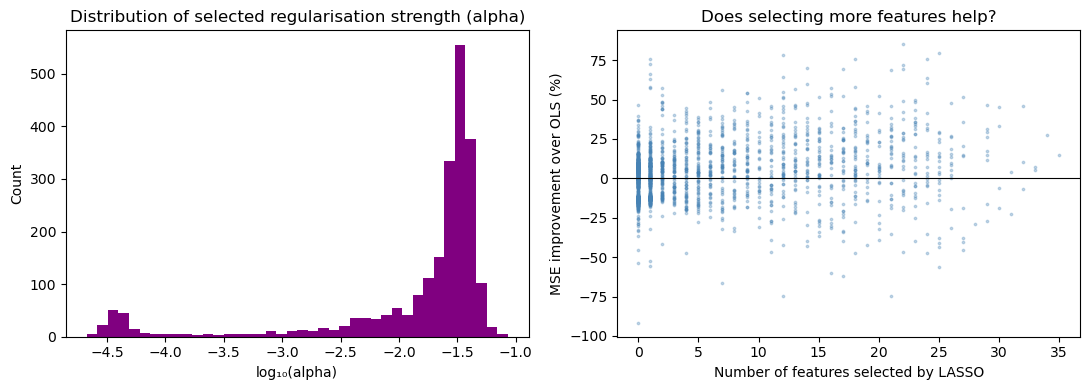

In [8]:
has_direct_struct = struct_present > 0    # edges present in ≥1 subject

direct_selected   = 0
direct_not_selected = 0
no_struct_at_all  = 0

for idx, feats in enumerate(selected_features):
    if not has_direct_struct[idx]:
        no_struct_at_all += 1
        continue
    if feats is not None and idx in feats:
        direct_selected += 1
    else:
        direct_not_selected += 1

total_with_struct = direct_selected + direct_not_selected
print(f"Edges with at least one structural connection: {total_with_struct}")
print(f"  LASSO selected the direct s_ij:          {direct_selected} ({direct_selected/total_with_struct*100:.1f}%)")
print(f"  LASSO did NOT select the direct s_ij:    {direct_not_selected} ({direct_not_selected/total_with_struct*100:.1f}%)")
print(f"Edges with no structural connection at all: {no_struct_at_all}")

# Alpha distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(lasso_alpha + 1e-10), bins=40, color="purple", edgecolor="none")
axes[0].set_xlabel("log₁₀(alpha)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of selected regularisation strength (alpha)")

# MSE improvement vs n_selected
axes[1].scatter(lasso_n_selected, pct_better, s=3, alpha=0.3, color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Number of features selected by LASSO")
axes[1].set_ylabel("MSE improvement over OLS (%)")
axes[1].set_title("Does selecting more features help?")

plt.tight_layout()
plt.savefig(str(figure_dir / 'alpha_and_nfeatures.png'), dpi=180, bbox_inches="tight")
plt.show()

## Structural Feature Selection

The median number of structural features selected per functional edge is 1, and 34.2% of functional edges select zero features. Out of 1522 functional edges that have a structural connection in at least one subject, LASSO selects the direct structrual connection in only 0.3% of the cases, and prefers to select distant structural connections, especially regions with a high degree. This suggests that functional connectivity between regions is more correlated with shared ’hubs’ rather than direct structural connections.

## Conclusion

This report explored the structural-functional connectivity relationship, where we explored the connectomes as a function of threshold parameters, and modelled functional connectivity from structural connectivity using regression.

Core Task 1 shows that FA thresholding acts as a tissue-type filter, with structural graph properties best shown at FA = 0.2−0.3. Functional connectome estimation required shrinkage regularisation given that the sample has far fewer time points than regions. Core Task 2 showed that the structural-functional relationship is weak and broadly linear at the per edge level (around 7% variance explained), with indirect two-step connectivity matching or slightly outperforming direct connections by both AIC and LOOCV SSE. This suggests that the presence of some structural route between two regions matters more than the specific path when predicting a functional connection. Across subjects, global linear models generalised surprisingly well, which shows a stable structural-functional relationship between different individuals. In LASSO regression, the direct structural connection was selected in only 0.3% of functional edges, and hub-connected structural paths were preferred instead.

Several limitations should be considered in this project. The small sample size of 19 subjects heavily limits the statistical power of the results. All functional connectivity was estimated from resting-state data. An interesting extension of this project could be to explore the structural-functional relationship with task-evoked functional connectivity. Nevertheless, these findings show that structural white matter connectivity is a weak predictor of resting state functional connectivity, and that the structural connectome acts more as a scaffold for functional connections, where functional connectivity shows dynamics that are not captured by static anatomy alone.

**Verification note:** The approximately 7% explained variance in the original conclusion refers to the subject-specific global models, not a measured average across per-edge regressions. The LASSO interpretation is subject to the validation limitation noted above.